<a href="https://colab.research.google.com/github/liv3812/vibes/blob/main/frequencia%20natural%20teste%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importar as Bibliotecas

In [12]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import os
import matplotlib.pyplot as plt

Ler os dados do arquivo do ensaio

In [13]:
f1t2 = pd.read_csv('/content/baja_front_rig1_turma1.txt', sep='\t', skiprows=10, encoding='latin1')
f1t2.set_index('Time (s)', inplace = True)
f1t2.rename(columns={"AI 1/AI 1 (m/s2)": "Acc1 m/s2", "AI 2/AI 2 (m/s2)": "Acc2 m/s2", "AI 3/AI 3 (V)": "Força (V)", "AI 4/AI 4 (V)": "Disp (V)" },  inplace = True)

Tabela dos dados lidos

In [14]:
f1t2

,Acc1 m/s2,Acc2 m/s2
Time (s),,
0.00000,-0.041862,-0.033547
0.00005,-0.039050,-0.034949
0.00010,-0.043208,-0.032947
0.00015,-0.039874,-0.031539
0.00020,-0.039578,-0.031124
...,...,...
10.04135,-0.001832,-0.007114
10.04140,-0.003386,-0.004108
10.04145,-0.001276,-0.000219


Gráfico da medição

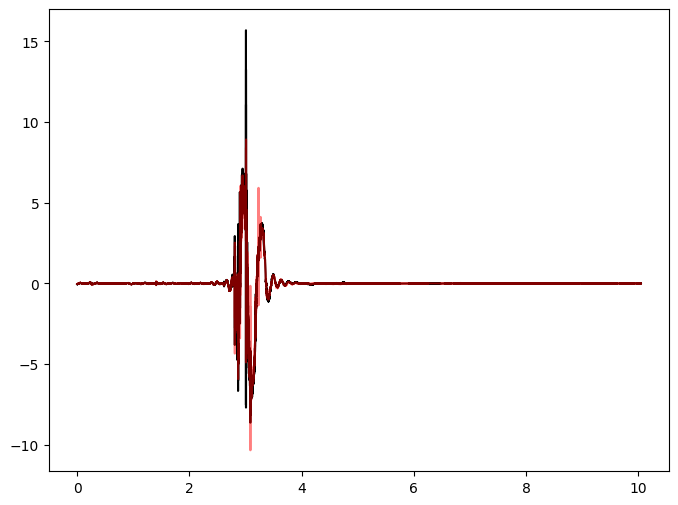

In [15]:
fig, ax = plt.subplots(figsize=[8,6])

ax.plot(f1t2.index, f1t2['Acc1 m/s2'], 'k', label = 'Acc 1')
ax.plot(f1t2.index, f1t2['Acc2 m/s2'], 'r', label = 'Acc 2', alpha = 0.5)

Queremos caracterizar o amortecimento. Para isso, precisamos ver o decaimento da resposta. Entretanto, parte da resposta medida está muito relacionada à variação da entrada. Por isso, vamos verificar o decaimento apenas na parte final da resposta:

In [18]:
#Cortar região de interesse
u_np = np.array(f1t2.loc[3.4:4.3]['Acc1 m/s2'])
time_np = np.array(f1t2.loc[3.4:4.3].index) # Aligned time_np to u_np's range

# Plotando os resultados
fig = go.Figure()
fig.add_trace(go.Scatter(x=time_np, y=u_np, mode='lines', name='Acc1 m/s2 (Filtered)', line=dict(color='red')))

fig.update_layout(
    xaxis_title='Tempo(s)',
    yaxis_title='Aceleração (m/s^2)'
)

fig.show()

In [25]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Configurações de arquivos e bandas
configs = [
    {'path': '/content/baja_front_rig1_turma1.txt', 't_start': 3.4, 't_end': 4.3},
    {'path': '/content/baja_front_rig2_turma1.txt', 't_start': 2.5, 't_end': 3.2},
    {'path': '/content/baja_tras_rig1_turma1.txt', 't_start': 2.42, 't_end': 3.6},
    {'path': '/content/baja_tras_rig2_turma1.txt', 't_start': 2.95, 't_end': 3.8}
]

# Dicionário para armazenar dados processados para a FFT
processed_data = {}

print("Gerando gráficos das bandas de tempo...")

for config in configs:
    file_path = config['path']
    t_start, t_end = config['t_start'], config['t_end']
    name = file_path.split('/')[-1]

    # Carregar e filtrar
    df_temp = pd.read_csv(file_path, sep='\t', skiprows=10, encoding='latin1')
    df_temp.set_index('Time (s)', inplace=True)
    df_temp.rename(columns={'AI 1/AI 1 (m/s2)': 'Acc1 m/s2'}, inplace=True)

    subset = df_temp.loc[t_start:t_end]
    u = subset['Acc1 m/s2'].values
    t = subset.index.values

    processed_data[name] = {'u': u, 't': t, 't_start': t_start, 't_end': t_end}

    # Plotar tempo
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=t, y=u, mode='lines', name=name))
    fig.update_layout(
        title=f'Sinal no Tempo - {name} [{t_start}s - {t_end}s]',
        xaxis_title='Tempo (s)',
        yaxis_title='Aceleração (m/s²)'
    )
    fig.show()

Gerando gráficos das bandas de tempo...


In [28]:
print("Gerando gráficos da FFT e identificando frequências naturais...")

for name, data in processed_data.items():
    u = data['u']
    t = data['t']
    t_start, t_end = data['t_start'], data['t_end']

    if len(u) > 1:
        # 1. Cálculo da FFT
        dt = t[1] - t[0]
        n = len(u)
        u_detrended = u - np.mean(u)
        fft_vals = np.fft.rfft(u_detrended)
        freqs = np.fft.rfftfreq(n, d=dt)
        mags = np.abs(fft_vals) * 2 / n

        # 2. Identificar a Frequência Natural (Pico de maior magnitude entre 0 e 50Hz)
        mask = (freqs <= 50)
        peak_idx = np.argmax(mags[mask])
        natural_freq = freqs[mask][peak_idx]

        print(f"{name}: Frequência Natural Identificada = {natural_freq:.2f} Hz")

        # 3. Plotar FFT
        fig_fft = go.Figure()
        fig_fft.add_trace(go.Scatter(x=freqs, y=mags, mode='lines', name=f'FFT {name}', line=dict(color='red')))

        # Adicionar marcador no pico
        fig_fft.add_annotation(x=natural_freq, y=mags[mask][peak_idx],
                               text=f"{natural_freq:.2f} Hz", showarrow=True, arrowhead=1)

        fig_fft.update_layout(
            title=f'FFT - {name}<br><sup>Frequência Natural: {natural_freq:.2f} Hz | Banda: [{t_start}s, {t_end}s]</sup>',
            xaxis_title='Frequência (Hz)',
            yaxis_title='Amplitude',
            xaxis_range=[0, 50]
        )
        fig_fft.show()
    else:
        print(f'Erro: Dados insuficientes para FFT de {name}.')

Gerando gráficos da FFT e identificando frequências naturais...
baja_front_rig1_turma1.txt: Frequência Natural Identificada = 6.67 Hz


baja_front_rig2_turma1.txt: Frequência Natural Identificada = 7.14 Hz


baja_tras_rig1_turma1.txt: Frequência Natural Identificada = 2.54 Hz


baja_tras_rig2_turma1.txt: Frequência Natural Identificada = 4.71 Hz
